# Tai Dinh, Week 8, Evaluation Expansion

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn import linear_model as lm
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [ ]:
#custom mdape function
def mdape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true))

# Load in CSV's, Remove Outliers, and Select Features

In [ ]:
test_df = pd.read_csv('/content/test_df.csv')
valid_df = pd.read_csv('/content/valid_df.csv')
train_df = pd.read_csv('/content/train_df.csv')

In [ ]:
train_df = train_df[(train_df["ClosePrice"] <= 600000000) & (train_df["ClosePrice"] > 0)]

In [ ]:
cols = ["LivingArea", "Age", "Bed/Bath Ratio", "LivingArea/LotSizeArea", "Living Area per Bedroom", "ParkingTotal", "BathroomsTotalInteger", "GarageSpaces", "AttachedGarageYN", "PoolPrivateYN", "ViewYN", "BedroomsTotal", "Stories", "AssociationFee"
, "AssociationFeeFrequency_Monthly", "AssociationFeeFrequency_None", "AssociationFeeFrequency_Quarterly", "AssociationFeeFrequency_SemiAnnually", "WaterfrontYN", "BasementYN", "FireplaceYN", "FireplacesTotal", "LotSizeArea", "NewConstructionYN"
, 'CountyOrParish_Amador',
 'CountyOrParish_Butte',
 'CountyOrParish_Calaveras',
 'CountyOrParish_Clark',
 'CountyOrParish_Colusa',
 'CountyOrParish_Contra Costa',
 'CountyOrParish_El Dorado',
 'CountyOrParish_Foreign Country',
 'CountyOrParish_Fresno',
 'CountyOrParish_Glenn',
 'CountyOrParish_Humboldt',
 'CountyOrParish_Imperial',
 'CountyOrParish_Inyo',
 'CountyOrParish_Kern',
 'CountyOrParish_Kings',
 'CountyOrParish_Lake',
 'CountyOrParish_Lassen',
 'CountyOrParish_Los Angeles',
 'CountyOrParish_Madera',
 'CountyOrParish_Marin',
 'CountyOrParish_Mariposa',
 'CountyOrParish_Mendocino',
 'CountyOrParish_Merced',
 'CountyOrParish_Modoc',
 'CountyOrParish_Mono',
 'CountyOrParish_Monterey',
 'CountyOrParish_Napa',
 'CountyOrParish_Nevada',
 'CountyOrParish_Orange',
 'CountyOrParish_Other',
 'CountyOrParish_Other State',
 'CountyOrParish_Placer',
 'CountyOrParish_Plumas',
 'CountyOrParish_Riverside',
 'CountyOrParish_Sacramento',
 'CountyOrParish_San Benito',
 'CountyOrParish_San Bernardino',
 'CountyOrParish_San Diego',
 'CountyOrParish_San Francisco',
 'CountyOrParish_San Joaquin',
 'CountyOrParish_San Luis Obispo',
 'CountyOrParish_San Mateo',
 'CountyOrParish_Santa Barbara',
 'CountyOrParish_Santa Clara',
 'CountyOrParish_Santa Cruz',
 'CountyOrParish_Shasta',
 'CountyOrParish_Sierra',
 'CountyOrParish_Siskiyou',
 'CountyOrParish_Solano',
 'CountyOrParish_Sonoma',
 'CountyOrParish_Stanislaus',
 'CountyOrParish_Sutter',
 'CountyOrParish_Tehama',
 'CountyOrParish_Trinity',
 'CountyOrParish_Tulare',
 'CountyOrParish_Tuolumne',
 'CountyOrParish_Ventura',
 'CountyOrParish_Yolo',
 'CountyOrParish_Yuba',
 'DistrictName_Apple Valley Unified',
 'DistrictName_Bear Valley Unified',
 'DistrictName_Beaumont Unified',
 'DistrictName_Capistrano Unified',
 'DistrictName_Chico Unified',
 'DistrictName_Chino Valley Unified',
 'DistrictName_Coachella Valley Unified',
 'DistrictName_Conejo Valley Unified',
 'DistrictName_Corona-Norco Unified',
 'DistrictName_Desert Sands Unified',
 'DistrictName_Fontana Unified',
 'DistrictName_Fremont Unified',
 'DistrictName_Garden Grove Unified',
 'DistrictName_Glendale Unified',
 'DistrictName_Hemet Unified',
 'DistrictName_Hesperia Unified',
 'DistrictName_Irvine Unified',
 'DistrictName_Lake Elsinore Unified',
 'DistrictName_Long Beach Unified',
 'DistrictName_Los Angeles Unified',
 'DistrictName_Lucia Mar Unified',
 'DistrictName_Moreno Valley Unified',
 'DistrictName_Morongo Unified',
 'DistrictName_Mt. Diablo Unified',
 'DistrictName_Murrieta Valley Unified',
 'DistrictName_Newport-Mesa Unified',
 'DistrictName_None',
 'DistrictName_Oakland Unified',
 'DistrictName_Oceanside Unified',
 'DistrictName_Orange Unified',
 'DistrictName_Other',
 'DistrictName_Palm Springs Unified',
 'DistrictName_Pasadena Unified',
 'DistrictName_Placentia-Yorba Linda Unified',
 'DistrictName_Poway Unified',
 'DistrictName_Redlands Unified',
 'DistrictName_Rim of the World Unified',
 'DistrictName_Riverside Unified',
 'DistrictName_Saddleback Valley Unified',
 'DistrictName_San Bernardino City Unified',
 'DistrictName_San Diego Unified',
 'DistrictName_San Jose Unified',
 'DistrictName_San Marcos Unified',
 'DistrictName_San Ramon Valley Unified',
 'DistrictName_Simi Valley Unified',
 'DistrictName_Temecula Valley Unified',
 'DistrictName_Torrance Unified',
 'DistrictName_Vista Unified',
 'DistrictName_West Contra Costa Unified',
        'Wood', 'Carpet', 'Tile', 'Laminate', 'Bamboo', 'Concrete', 'Vinyl', 'Stone', 'Brick']
X_train = train_df[cols]
Y_train = train_df["ClosePrice"]

X_valid = valid_df[cols]
Y_valid = valid_df["ClosePrice"]

X_test = test_df[cols]
Y_test = test_df["ClosePrice"]

#Baseline Model Metrics

r^2: 0.7474580608459424
RMSE: 19634924.4823088
MAPE: 0.28432668887325624
MDAPE: 0.1717300670299321


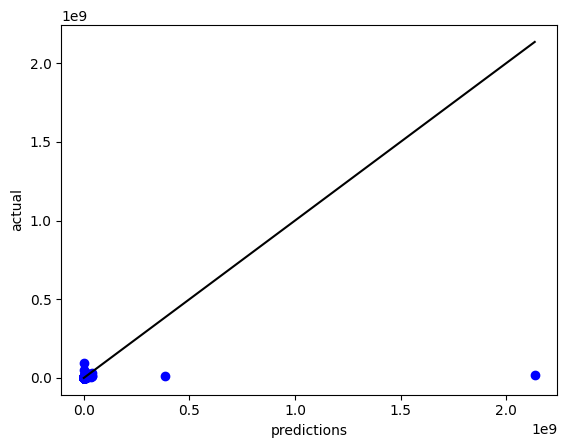

In [ ]:
base_model = lm.LinearRegression()
base_model.fit(X_train, np.log(Y_train))



#validation set metrics
vlin_preds = np.exp(base_model.predict(X_valid))
print(f"r^2: {r2_score(np.log(Y_valid), np.log(vlin_preds))}")
print(f"RMSE: {root_mean_squared_error(Y_valid, vlin_preds)}")
print(f"MAPE: {mape(Y_valid, vlin_preds)}")
print(f"MDAPE: {mdape(Y_valid, vlin_preds)}")

#plotting predictions vs. actual
plt.scatter(vlin_preds, Y_valid, color='blue')
plt.plot([0, max(vlin_preds)], [0, max(vlin_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

r^2: 0.7431341266075399
RMSE: 311265682.32014227
MAPE: 5.551916319099581
MDAPE: 0.17041016533181025


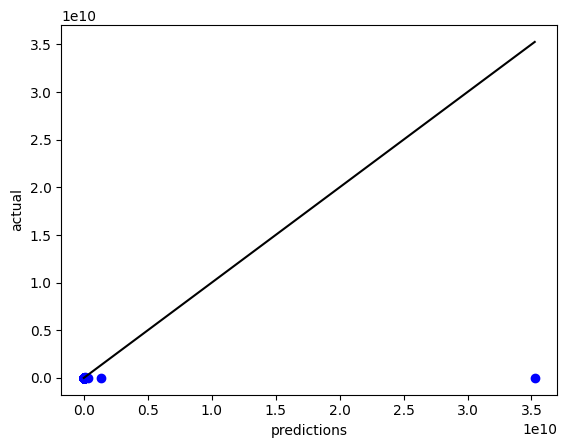

In [ ]:
#test set metrics
tlin_preds = np.exp(base_model.predict(X_test))
print(f"r^2: {r2_score(np.log(Y_test), np.log(tlin_preds))}")
print(f"RMSE: {root_mean_squared_error(Y_test, tlin_preds)}")
print(f"MAPE: {mape(Y_test, tlin_preds)}")
print(f"MDAPE: {mdape(Y_test, tlin_preds)}")

#plotting predictions vs. actual
plt.scatter(tlin_preds, Y_test, color='blue')
plt.plot([0, max(tlin_preds)], [0, max(tlin_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

#Decision Tree Regressor

In [ ]:
#initialize decision tree regressor
tree = DecisionTreeRegressor(random_state=30, max_depth = 40, min_samples_split = 150)

r^2: 0.743913029021217
RMSE: 1316355.3661619457
MAPE: 0.26734039412465366
MDAPE: 0.15609085097021896


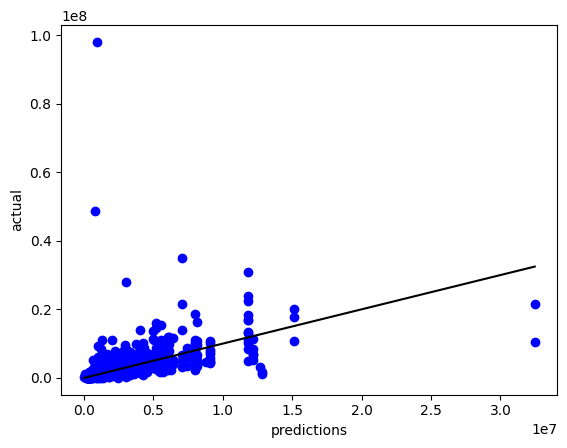

In [ ]:
tree.fit(X_train, np.log(Y_train))

#validation set metrics
vtree_preds = np.exp(tree.predict(X_valid))
print(f"r^2: {r2_score(np.log(Y_valid), np.log(vtree_preds))}")
print(f"RMSE: {root_mean_squared_error(Y_valid, vtree_preds)}")
print(f"MAPE: {mape(Y_valid, vtree_preds)}")
print(f"MDAPE: {mdape(Y_valid, vtree_preds)}")

#plotting predictions vs. actual
plt.scatter(vtree_preds, Y_valid, color='blue')
plt.plot([0, max(vtree_preds)], [0, max(vtree_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

r^2: 0.7596320256699698
RMSE: 1012628.4467204576
MAPE: 0.3212731718710589
MDAPE: 0.15568208992973187


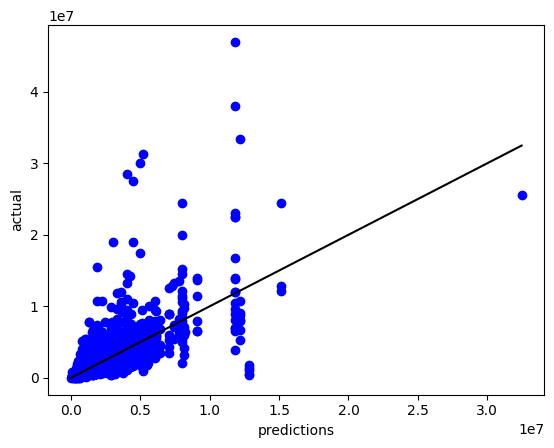

In [ ]:
#test set metrics
testtree_preds = np.exp(tree.predict(X_test))
print(f"r^2: {r2_score(np.log(Y_test), np.log(testtree_preds))}")
print(f"RMSE: {root_mean_squared_error(Y_test, testtree_preds)}")
print(f"MAPE: {mape(Y_test, testtree_preds)}")
print(f"MDAPE: {mdape(Y_test, testtree_preds)}")

#plotting predictions vs. actual
plt.scatter(testtree_preds, Y_test, color='blue')
plt.plot([0, max(testtree_preds)], [0, max(testtree_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

#Random Forest Regressor

r^2: 0.7750181351408815
RMSE: 1276910.989617903
MAPE: 0.24957372014322748
MDAPE: 0.14834459550841683


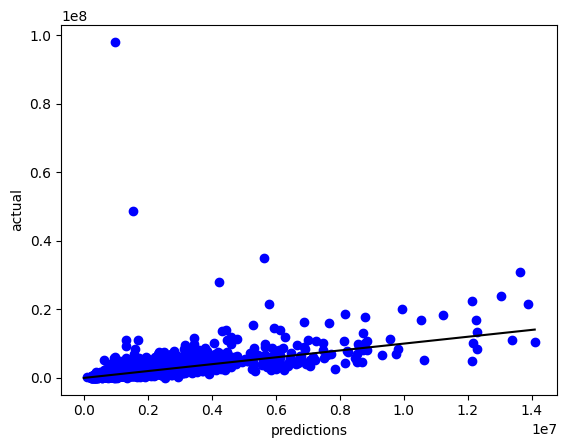

In [ ]:
#define random forest regressor
rf = RandomForestRegressor(random_state=30, max_depth = 40, min_samples_split = 150)
rf.fit(X_train, np.log(Y_train))

#validation set metrics
vrf_preds = np.exp(rf.predict(X_valid))
print(f"r^2: {r2_score(np.log(Y_valid), np.log(vrf_preds))}")
print(f"RMSE: {root_mean_squared_error(Y_valid, vrf_preds)}")
print(f"MAPE: {mape(Y_valid, vrf_preds)}")
print(f"MDAPE: {mdape(Y_valid, vrf_preds)}")

#plotting predictions vs. actual
plt.scatter(vrf_preds, Y_valid, color='blue')
plt.plot([0, max(vrf_preds)], [0, max(vrf_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

r^2: 0.7887861826752062
RMSE: 969700.3127157477
MAPE: 0.30491946762278993
MDAPE: 0.14852936077737877


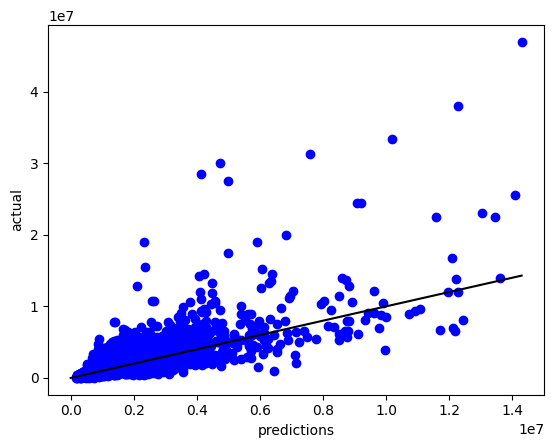

In [ ]:
#test set metrics
trf_preds = np.exp(rf.predict(X_test))
print(f"r^2: {r2_score(np.log(Y_test), np.log(trf_preds))}")
print(f"RMSE: {root_mean_squared_error(Y_test, trf_preds)}")
print(f"MAPE: {mape(Y_test, trf_preds)}")
print(f"MDAPE: {mdape(Y_test, trf_preds)}")

#plotting predictions vs. actual
plt.scatter(trf_preds, Y_test, color='blue')
plt.plot([0, max(trf_preds)], [0, max(trf_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

#Gradient Boosting

r^2: 0.7759719823061735
RMSE: 1259424.846037115
MAPE: 0.2551540933766861
MDAPE: 0.1614034946236559


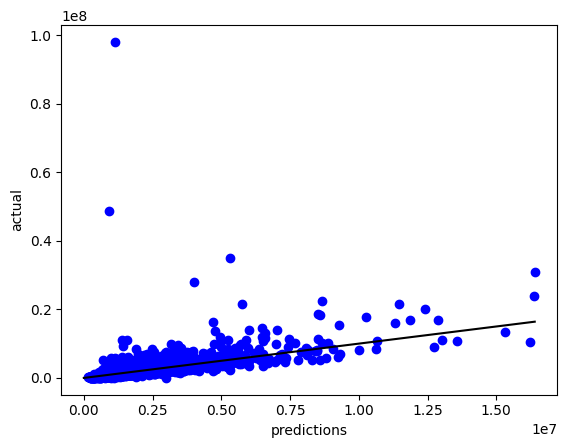

In [ ]:
gradmodel = xgb.XGBRegressor(objective='reg:squarederror',
    n_estimators= 125,
    max_depth=8,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='rmse')
gradmodel.fit(X_train, np.log(Y_train))
vgrad_pred = np.exp(gradmodel.predict(X_valid))

#validation set metrics
print(f"r^2: {r2_score(np.log(Y_valid), np.log(vgrad_pred))}")
print(f"RMSE: {root_mean_squared_error(Y_valid, vgrad_pred)}")
print(f"MAPE: {mape(Y_valid, vgrad_pred)}")
print(f"MDAPE: {mdape(Y_valid, vgrad_pred)}")

#plotting predictions vs. actual
plt.scatter(vgrad_pred, Y_valid, color='blue')
plt.plot([0, max(vgrad_pred)], [0, max(vgrad_pred)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

r^2: 0.7884349593602784
RMSE: 923494.3211877549
MAPE: 0.3060568252248248
MDAPE: 0.16194644736842106


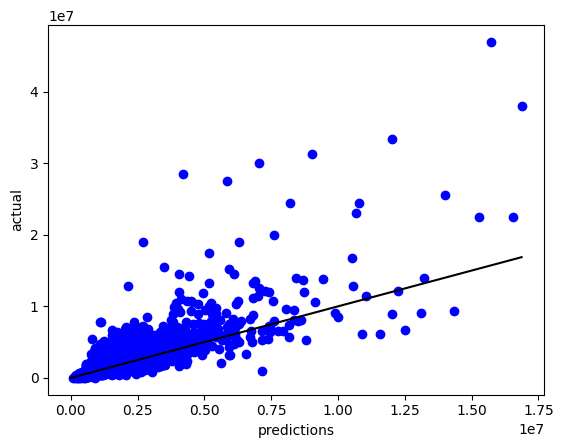

In [ ]:
testgrad_pred = np.exp(gradmodel.predict(X_test))

#test set metrics
print(f"r^2: {r2_score(np.log(Y_test), np.log(testgrad_pred))}")
print(f"RMSE: {root_mean_squared_error(Y_test, testgrad_pred)}")
print(f"MAPE: {mape(Y_test, testgrad_pred)}")
print(f"MDAPE: {mdape(Y_test, testgrad_pred)}")

#plotting predictions vs. actual
plt.scatter(testgrad_pred, Y_test, color='blue')
plt.plot([0, max(testgrad_pred)], [0, max(testgrad_pred)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

#Metrics Summary

In [ ]:
summar = pd.DataFrame(columns = ["Model", "r^2", "RMSE", "MAPE", "MDAPE"])
summar["Model"] = ["Linear Regression", "Decision Tree Regressor", "Random Forest Regressor", "Gradient Boost"]
summar['r^2'] = [r2_score(np.log(Y_test), np.log(tlin_preds)), r2_score(np.log(Y_test), np.log(testtree_preds)), r2_score(np.log(Y_test), np.log(trf_preds)), r2_score(np.log(Y_test), np.log(testgrad_pred))]
summar['RMSE'] = [root_mean_squared_error(Y_test, tlin_preds), root_mean_squared_error(Y_test, testtree_preds), root_mean_squared_error(Y_test, trf_preds), root_mean_squared_error(Y_test, testgrad_pred)]
summar['MAPE'] = [mape(Y_test, tlin_preds), mape(Y_test, testtree_preds), mape(Y_test, trf_preds), mape(Y_test, testgrad_pred)]
summar['MDAPE'] = [mdape(Y_test, tlin_preds), mdape(Y_test, testtree_preds), mdape(Y_test, trf_preds), mdape(Y_test, testgrad_pred)]
summar
#summar.to_csv('metrics_summary.csv', index=False)

,Model,r^2,RMSE,MAPE,MDAPE
0,Linear Regression,0.743134,3.112657e+08,5.551916,0.170410
1,Decision Tree Regressor,0.759632,1.012628e+06,0.321273,0.155682
2,Random Forest Regressor,0.788786,9.697003e+05,0.304919,0.148529
3,Gradient Boost,0.788435,9.234943e+05,0.306057,0.161946


Linear Regression is the weakest model by MdAPE, which I'm valuing as the most valuable metric because housing prices have some high outliers. By MDAPE, Decision Tree Regressors are the strongest model, but we have the trade-off of longer computations. By $r^2$, Gradient Boost accounts for the most variance in the model though trails behind in terms of MDAPE. Random Forests and Gradient Boost are my two preferred models here.

#How do these models perform on different price bands?

In [ ]:
#taking percentiles to split data into different price bands
target_percentiles = [0.5, 0.8]

print(test_df['ClosePrice'].quantile(target_percentiles))
first_percentile = test_df['ClosePrice'].quantile(target_percentiles[0])
second_percentile = test_df['ClosePrice'].quantile(target_percentiles[1])

first_band = test_df[test_df['ClosePrice'] <= first_percentile]
second_band = test_df[(test_df['ClosePrice'] > first_percentile) & (test_df['ClosePrice'] <= second_percentile)]
third_band = test_df[test_df['ClosePrice'] > second_percentile]

0.5     925000.0
0.8    1665000.0
Name: ClosePrice, dtype: float64


r^2: -11.12632086970113
RMSE: 649573.1312109837
MAPE: 0.9999716495380052
MDAPE: 0.9999788289585272


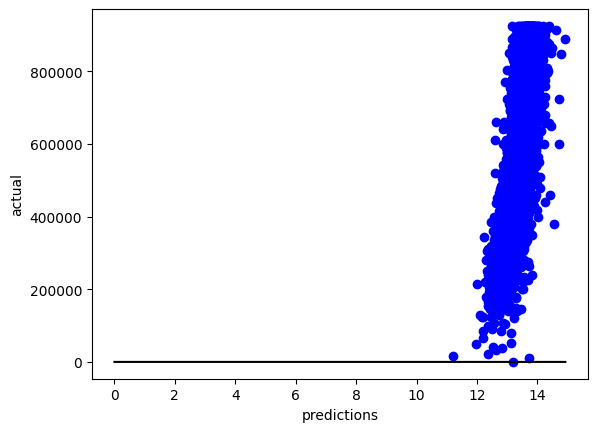

In [ ]:
#first percentile  metrics
first_preds = gradmodel.predict(first_band[cols])
print(f"r^2: {r2_score(first_band["ClosePrice"], first_preds)}")
print(f"RMSE: {root_mean_squared_error(first_band["ClosePrice"], first_preds)}")
print(f"MAPE: {mape(first_band["ClosePrice"], first_preds)}")
print(f"MDAPE: {mdape(first_band["ClosePrice"], first_preds)}")

#plotting predictions vs. actual
plt.scatter(first_preds, first_band["ClosePrice"], color='blue')
plt.plot([0, max(first_preds)], [0, max(first_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

r^2: -34.32963407558848
RMSE: 1260325.498893279
MAPE: 0.9999884496876138
MDAPE: 0.9999885890132725


Text(0, 0.5, 'actual')

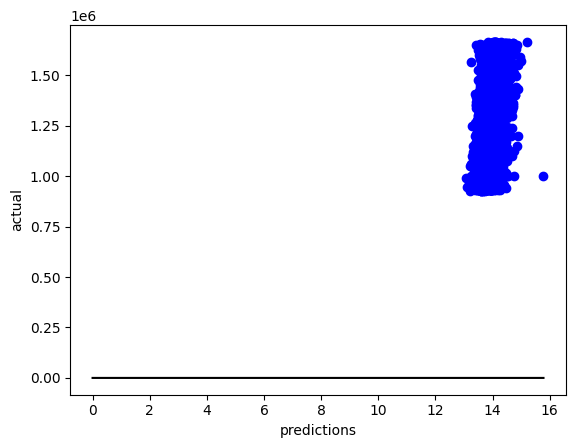

In [ ]:
#second percentile metrics
second_preds = gradmodel.predict(second_band[cols])
print(f"r^2: {r2_score(second_band["ClosePrice"], second_preds)}")
print(f"RMSE: {root_mean_squared_error(second_band["ClosePrice"], second_preds)}")
print(f"MAPE: {mape(second_band["ClosePrice"], second_preds)}")
print(f"MDAPE: {mdape(second_band["ClosePrice"], second_preds)}")

#plotting predictions vs. actual
plt.scatter(second_preds, second_band["ClosePrice"], color='blue')
plt.plot([0, max(second_preds)], [0, max(second_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')

r^2: -1.3521169059782152
RMSE: 4111414.5654276498
MAPE: 0.999994198211488
MDAPE: 0.9999939336454517


Text(0, 0.5, 'actual')

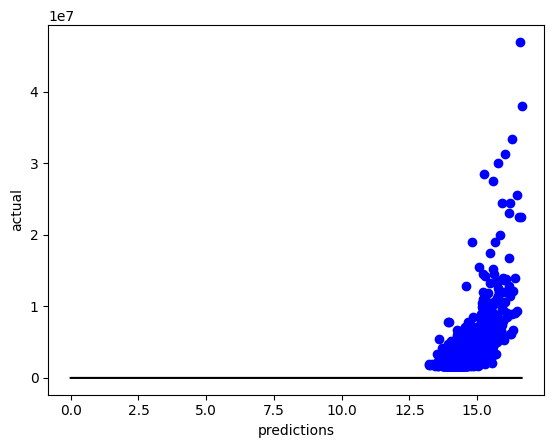

In [ ]:
#third percentile metrics
third_preds = gradmodel.predict(third_band[cols])
print(f"r^2: {r2_score(third_band["ClosePrice"], third_preds)}")
print(f"RMSE: {root_mean_squared_error(third_band["ClosePrice"], third_preds)}")
print(f"MAPE: {mape(third_band["ClosePrice"], third_preds)}")
print(f"MDAPE: {mdape(third_band["ClosePrice"], third_preds)}")

#plotting predictions vs. actual
plt.scatter(third_preds, third_band["ClosePrice"], color='blue')
plt.plot([0, max(third_preds)], [0, max(third_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')